# Benchmarking against MASIF ligand

In [62]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import numpy as np
import biotite.structure as bs
import biotite.structure.io.pdb as pdb
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
import json
import ast
 
from atomica.data.converter import ligand_utils
from atomica.data import filter_for_segment

MASIF_LIGAND_LABELS = ["ADP", "COA", "FAD", "HEM", "NAD", "NAP", "SAM"]

MASIF_DATA_DIR = "/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/baselines/masif/data/masif_ligand/lists/"
MASIF_LIGAND_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/00c-ligand_coords/"
PDB_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/00b-pdbs_assembly/"
ATOMICA_DATA_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/"
BASELINE_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/"

sns.set_context("notebook")
baseline_color = '#B0B0B0'
atomica_color = '#00C4C7'
ensemble_color = '#059094'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def ensemble_predictions(df):
    required_columns = ['id', 'label', 'pred', 'pred_probability']
    if not all(col in df.columns for col in required_columns):
        raise ValueError(f"Missing required columns: {required_columns}")
    ensemble_df = df.groupby('id').agg(
        label=('label', 'first'),
        pred=('pred', list),
        pred_mode=('pred', lambda x: np.argmax(np.bincount(x))),
        pred_mode_probability=('pred_probability', lambda x: np.argmax(np.mean(x, axis=0))),
        pred_probability=('pred_probability', lambda x: np.mean(x, axis=0)),
    ).reset_index()
    return ensemble_df

In [3]:
RESULTS_DICT = {}

## ATOMICA Ligand Predictions

In [4]:
def _parse_prob(x):
    """Parse a probability vector coming from CSV (often stored as a string)."""
    if isinstance(x, np.ndarray):
        return x.astype(float)
    if isinstance(x, list):
        return np.array(x, dtype=float)
    if isinstance(x, str):
        s = x.strip()
        # e.g. "[0.1, 0.2, 0.3]" (commas) or "[0.1 0.2 0.3]" (spaces)
        if "," in s:
            return np.array(ast.literal_eval(s), dtype=float)
        return np.fromstring(s.strip("[]"), sep=" ")
    return np.array([x], dtype=float)

model_ckpts = [
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_142/checkpoint/epoch186_step15895.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_206/checkpoint/epoch138_step11815.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_174/checkpoint/epoch140_step11985.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_196/checkpoint/epoch253_step21590.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_150/checkpoint/epoch286_step24395.ckpt',

#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_204/checkpoint/epoch299_step18900.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_143/checkpoint/epoch236_step14931.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_181/checkpoint/epoch275_step17388.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_162/checkpoint/epoch284_step17955.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_190/checkpoint/epoch196_step12411.ckpt',

#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_205/checkpoint/epoch222_step10258.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_180/checkpoint/epoch176_step8142.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_198/checkpoint/epoch273_step12604.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_149/checkpoint/epoch185_step8556.ckpt',
#  '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_188/checkpoint/epoch223_step10304.ckpt',
]

test_preds = []
for ckpt in model_ckpts:
    if os.path.exists(os.path.join(os.path.dirname(ckpt), 'test_preds.csv')):
        test_preds.append(os.path.join(os.path.dirname(ckpt), 'test_preds.csv'))
    elif os.path.exists(os.path.join(os.path.dirname(ckpt), 'test_preds.parquet')):
        test_preds.append(os.path.join(os.path.dirname(ckpt), 'test_preds.parquet'))
    else:
        raise ValueError(f"No test predictions found for {ckpt}")

test_results = []
for i, (ckpt, test_preds) in enumerate(zip(model_ckpts, test_preds)):
    if test_preds.endswith('.csv'):
        seed_results = pd.read_csv(test_preds)
    elif test_preds.endswith('.parquet'):
        seed_results = pd.read_parquet(test_preds)
    else:
        raise ValueError(f"Unknown file type for {test_preds}")
    if 'Unnamed: 0' in seed_results.columns:
        seed_results.drop(columns=['Unnamed: 0'], inplace=True)
    seed_results['pred_probability'] = seed_results['pred_probability'].apply(lambda x: _parse_prob(x))
    seed_results['seed'] = i
    test_results.append(seed_results)
atomica_results_df = pd.concat(test_results)

In [5]:
atomica_ensemble = ensemble_predictions(atomica_results_df)
RESULTS_DICT['ATOMICA'] = (atomica_results_df, atomica_ensemble)

ensemble_acc = atomica_ensemble['pred_mode_probability'] == atomica_ensemble['label']
no_ensemble_acc = atomica_results_df['pred'] == atomica_results_df['label']
print('Accuracy: ATOMICA ensemble {:.4f}, no ensemble {:.4f}'.format(ensemble_acc.mean(), no_ensemble_acc.mean()))

Accuracy: ATOMICA ensemble 0.8587, no ensemble 0.7623


## MASIF predictions

In [6]:
MASIF_PREDICTIONS_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/test_set_predictions"

In [7]:
masif_results = []
for pred_fname in glob(f"{MASIF_PREDICTIONS_DIR}/*_logits.npy"):
    item_id = os.path.basename(pred_fname).replace("_logits.npy", "")
    labels = np.load(os.path.join(MASIF_PREDICTIONS_DIR, f"{item_id}_labels.npy"))
    preds = np.load(pred_fname)
    if preds.shape == (0, ):
        print(f"No predictions for {item_id}")
        continue
    elif preds.shape[1:] != (100, 1, 1, 7):
        print(f"Invalid shape for {item_id}: {preds.shape}")
        continue
    preds = preds.mean(axis=1).squeeze()
    if preds.ndim == 1:
        preds = preds[None, :]
    for label, pred in zip(labels, preds):
        masif_results.append({
            'receptor_id': item_id,
            'label': label,
            'ligand': MASIF_LIGAND_LABELS[label],
            'pred': pred.argmax(axis=0),
            'pred_probability': pred,
        })
masif_results_df = pd.DataFrame(masif_results)
masif_results_df['seed'] = 0 # no seeds for MASIF
masif_results_df['pred_accuracy'] = masif_results_df['label'] == masif_results_df['pred']
masif_results_df['id'] = masif_results_df['receptor_id'] + '_' + masif_results_df['ligand']

RESULTS_DICT['MASIF'] = (masif_results_df, masif_results_df)

No predictions for 3D36_ACB
No predictions for 2REQ_AB
No predictions for 1X7P_AB
No predictions for 2OWM_AC
No predictions for 3UQD_ACBD
No predictions for 1XX6_AB
No predictions for 4ZNL_A
No predictions for 4H6Q_A
No predictions for 5HMN_CE
No predictions for 4BLV_A
No predictions for 5L8J_AB


In [8]:
accuracy = masif_results_df['pred_accuracy'].mean()
print(f"MASIF Accuracy: {accuracy:.4f}")

MASIF Accuracy: 0.7871


### Merge the two results, since they don't have the exact same IDs
Also group the results by unique receptor and ligand pairs, as some receptors have multiple identical ligands.

In [9]:
atomica_ensemble['receptor_id'] = atomica_ensemble['id'].str.split('_').str[:2].str.join('_')
atomica_ensemble['ligand'] = atomica_ensemble['id'].str.split('_').str[-1]
atomica_ensemble['masif_id'] = atomica_ensemble['receptor_id'] + '_' + atomica_ensemble['ligand']
masif_results_df['masif_id'] = masif_results_df['receptor_id'] + '_' + masif_results_df['ligand']

In [10]:
match_masif = atomica_ensemble['masif_id'].isin(masif_results_df['masif_id'])
atomica_ensemble['pred_mode_accuracy'] = atomica_ensemble['pred_mode'] == atomica_ensemble['label']
atomica_ensemble['pred_mode_probability_accuracy'] = atomica_ensemble['pred_mode_probability'] == atomica_ensemble['label']
atomica_grouped_results_match_masif_df = atomica_ensemble[match_masif].groupby('masif_id').agg(
    pred_mode_accuracy=('pred_mode_accuracy', 'mean'),
    pred_mode_probability_accuracy=('pred_mode_probability_accuracy', 'mean'),
)
atomica_grouped_results_match_masif_df.mean()

pred_mode_accuracy                0.867725
pred_mode_probability_accuracy    0.866071
dtype: float64

In [11]:
masif_results_df.groupby('masif_id').agg(
    accuracy=('pred_accuracy', 'mean'),
).mean()

accuracy    0.80754
dtype: float64

### ESM2 and ESM3 MLP predictions

In [ ]:
data_file = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/esm2_embeddings/masif_ligand_pdbs_8A_pocket_only_test_esm2.parquet"
data_df = pd.read_parquet(data_file)

esm2_list = []
for seed in range(5):
    with open(f"{BASELINE_DIR}/models/esm2/esm2_mlp_dist8_finaldim64_dropout0.3_lr1e-3/seed{seed}/test_predictions.json", "r") as f:
        esm2_preds = json.load(f)
    results = {
        'id': data_df['id'],
        'pred_probability': esm2_preds['probabilities'],
        'label': data_df['label'],
    }
    esm2_results_df = pd.DataFrame(results)
    esm2_results_df['seed'] = 0
    esm2_results_df['pred'] = esm2_results_df['pred_probability'].apply(lambda x: np.argmax(x))
    esm2_list.append(esm2_results_df)
esm2 = pd.concat(esm2_list)
esm2['pred_probability'] = esm2['pred_probability'].apply(lambda x: np.array(x).astype(float))
esm2_ensemble = ensemble_predictions(esm2)

ensemble_acc = (esm2_ensemble['pred_mode_probability'] == esm2_ensemble['label']).mean()
no_ensemble_acc = (esm2['pred'] == esm2['label']).mean()
print('Accuracy: ESM2 ensemble {:.4f}, no ensemble {:.4f}'.format(ensemble_acc, no_ensemble_acc))

RESULTS_DICT['ESM2'] = (esm2, esm2_ensemble)

Accuracy: ESM2 ensemble 0.8844, no ensemble 0.8677


In [ ]:
data_file = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/esm3_embeddings/masif_ligand_pdbs_8A_pocket_only_test_esm3.parquet"
data_df = pd.read_parquet(data_file)

esm3_list = []
for seed in range(5):
    with open(f"{BASELINE_DIR}/models/esm3/esm3_mlp_dist8_finaldim512_dropout0.2_lr5e-4/seed{seed}/test_predictions.json", "r") as f:
        esm3_preds = json.load(f)
    results = {
        'id': data_df['id'],
        'pred_probability': esm3_preds['probabilities'],
        'label': data_df['label'],
    }
    esm3_results_df = pd.DataFrame(results)
    esm3_results_df['seed'] = 0
    esm3_results_df['pred'] = esm3_results_df['pred_probability'].apply(lambda x: np.argmax(x))
    esm3_list.append(esm3_results_df)
esm3 = pd.concat(esm3_list)
esm3['pred_probability'] = esm3['pred_probability'].apply(lambda x: np.array(x).astype(float))
esm3_ensemble = ensemble_predictions(esm3)

ensemble_acc = (esm3_ensemble['pred_mode_probability'] == esm3_ensemble['label']).mean()
no_ensemble_acc = (esm3['pred'] == esm3['label']).mean()
print('Accuracy: ESM3 ensemble {:.4f}, no ensemble {:.4f}'.format(ensemble_acc, no_ensemble_acc))

RESULTS_DICT['ESM3'] = (esm3, esm3_ensemble)


Accuracy: ESM3 ensemble 0.8801, no ensemble 0.8638


In [ ]:
data_file = f"{BASELINE_DIR}/models/esmc/embeddings/masif_ligand_pdbs_8A_pocket_only_test_esmc.parquet"
data_df = pd.read_parquet(data_file)

esmc_list = []
for seed in range(5):
    with open(f"{BASELINE_DIR}/esmc/esmc_mlp_dist_finaldim256_dropout0.3_lr1e-3/seed{seed}/test_predictions.json", "r") as f:
        esmc_preds = json.load(f)
    results = {
        'id': data_df['id'],
        'pred_probability': esmc_preds['probabilities'],
        'label': data_df['label'],
    }
    esmc_results_df = pd.DataFrame(results)
    esmc_results_df['seed'] = 0
    esmc_results_df['pred'] = esmc_results_df['pred_probability'].apply(lambda x: np.argmax(x))
    esmc_list.append(esmc_results_df)
esmc = pd.concat(esmc_list)
esmc['pred_probability'] = esmc['pred_probability'].apply(lambda x: np.array(x).astype(float))
esmc_ensemble = ensemble_predictions(esmc)

ensemble_acc = (esmc_ensemble['pred_mode_probability'] == esmc_ensemble['label']).mean()
no_ensemble_acc = (esmc['pred'] == esmc['label']).mean()
print('Accuracy: ESMC ensemble {:.4f}, no ensemble {:.4f}'.format(ensemble_acc, no_ensemble_acc))

RESULTS_DICT['ESMC'] = (esmc, esmc_ensemble)


Accuracy: ESMC ensemble 0.8330, no ensemble 0.8146


In [ ]:
data_file = f"{BASELINE_DIR}/models/saprot/embeddings/masif_ligand_pdbs_8A_pocket_only_test.parquet"
data_df = pd.read_parquet(data_file)

saprot_list = []
for seed in range(5):
    with open(f"{BASELINE_DIR}/saprot/saprot_mlp_dist_finaldim64_dropout0.1_lr1e-3/seed{seed}/test_predictions.json", "r") as f:
        saprot_preds = json.load(f)
    results = {
        'id': data_df['id'],
        'pred_probability': saprot_preds['probabilities'],
        'label': data_df['label'],
    }
    saprot_results_df = pd.DataFrame(results)
    saprot_results_df['seed'] = 0
    saprot_results_df['pred'] = saprot_results_df['pred_probability'].apply(lambda x: np.argmax(x))
    saprot_list.append(saprot_results_df)
saprot = pd.concat(saprot_list)
saprot['pred_probability'] = saprot['pred_probability'].apply(lambda x: np.array(x).astype(float))
saprot_ensemble = ensemble_predictions(saprot)

ensemble_acc = (saprot_ensemble['pred_mode_probability'] == saprot_ensemble['label']).mean()
no_ensemble_acc = (saprot['pred'] == saprot['label']).mean()
print('Accuracy: SaProt ensemble {:.4f}, no ensemble {:.4f}'.format(ensemble_acc, no_ensemble_acc))

RESULTS_DICT['SaProt'] = (saprot, saprot_ensemble)


Accuracy: SaProt ensemble 0.8000, no ensemble 0.8065


In [ ]:
data_file = f"{BASELINE_DIR}/MASIF/models/prostt5/embeddings/masif_ligand_pdbs_8A_pocket_only_test_aa.parquet"
data_df = pd.read_parquet(data_file)

prostt5_list = []
for seed in range(5):
    with open(f"{BASELINE_DIR}/prostt5/prostt5_mlp_dist_finaldim64_dropout0.3_lr1e-3/seed{seed}/test_predictions.json", "r") as f:
        prostt5_preds = json.load(f)
    results = {
        'id': data_df['id'],
        'pred_probability': prostt5_preds['probabilities'],
        'label': data_df['label'],
    }
    prostt5_results_df = pd.DataFrame(results)
    prostt5_results_df['seed'] = 0
    prostt5_results_df['pred'] = prostt5_results_df['pred_probability'].apply(lambda x: np.argmax(x))
    prostt5_list.append(prostt5_results_df)
prostt5 = pd.concat(prostt5_list)
prostt5['pred_probability'] = prostt5['pred_probability'].apply(lambda x: np.array(x).astype(float))
prostt5_ensemble = ensemble_predictions(prostt5)

ensemble_acc = (prostt5_ensemble['pred_mode_probability'] == prostt5_ensemble['label']).mean()
no_ensemble_acc = (prostt5['pred'] == prostt5['label']).mean()
print('Accuracy: ProstT5 ensemble {:.4f}, no ensemble {:.4f}'.format(ensemble_acc, no_ensemble_acc))

RESULTS_DICT['ProstT5'] = (prostt5, prostt5_ensemble)


Accuracy: ProstT5 ensemble 0.8918, no ensemble 0.8805


## Joint models

In [29]:
def _parse_prob(x):
    """Parse a probability vector coming from CSV (often stored as a string)."""
    if isinstance(x, np.ndarray):
        return x.astype(float)
    if isinstance(x, list):
        return np.array(x, dtype=float)
    if isinstance(x, str):
        s = x.strip()
        # e.g. "[0.1, 0.2, 0.3]" (commas) or "[0.1 0.2 0.3]" (spaces)
        if "," in s:
            return np.array(ast.literal_eval(s), dtype=float)
        return np.fromstring(s.strip("[]"), sep=" ")
    return np.array([x], dtype=float)

model_ckpts = [
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_263/checkpoint/epoch69_step5950.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_262/checkpoint/epoch32_step2805.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_264/checkpoint/epoch49_step4250.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_283/checkpoint/epoch43_step3740.ckpt',
 '/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/models/version_271/checkpoint/epoch21_step1870.ckpt',
 ]

test_preds = []
for ckpt in model_ckpts:
    if os.path.exists(os.path.join(os.path.dirname(ckpt), 'test_preds.csv')):
        test_preds.append(os.path.join(os.path.dirname(ckpt), 'test_preds.csv'))
    elif os.path.exists(os.path.join(os.path.dirname(ckpt), 'test_preds.parquet')):
        test_preds.append(os.path.join(os.path.dirname(ckpt), 'test_preds.parquet'))
    else:
        raise ValueError(f"No test predictions found for {ckpt}")

test_results = []
for i, (ckpt, test_preds) in enumerate(zip(model_ckpts, test_preds)):
    if test_preds.endswith('.csv'):
        seed_results = pd.read_csv(test_preds)
        seed_results['pred_probability'] = seed_results['pred_probability'].apply(lambda x: _parse_prob(x))
    elif test_preds.endswith('.parquet'):
        seed_results = pd.read_parquet(test_preds)
    else:
        raise ValueError(f"Unknown file type for {test_preds}")
    if 'Unnamed: 0' in seed_results.columns:
        seed_results.drop(columns=['Unnamed: 0'], inplace=True)
    seed_results['seed'] = i
    test_results.append(seed_results)
atomica_esm2_results_df = pd.concat(test_results)
atomica_esm2_ensemble_results_df = ensemble_predictions(atomica_esm2_results_df)

pred_mode_acc = atomica_esm2_ensemble_results_df['pred_mode'] == atomica_esm2_ensemble_results_df['label']
pred_prob_acc = atomica_esm2_ensemble_results_df['pred_mode_probability'] == atomica_esm2_ensemble_results_df['label']
print(f"ATOMICA ESM2 Ensemble Accuracy: with mode {pred_mode_acc.mean():.4f}, with probability {pred_prob_acc.mean():.4f}")

RESULTS_DICT['ATOMICA ESM2'] = (atomica_esm2_results_df, atomica_esm2_ensemble_results_df)

ATOMICA ESM2 Ensemble Accuracy: with mode 0.8801, with probability 0.8844


In [30]:
# Super late integration
# Take the finetuned ATOMICA and ESM-MLP for the task
# and concatenat their final layer embeddings.
esm3_results = []

ESM3_MODEL_DIR = "/n/netscratch/mzitnik_lab/Lab/afang/ATOMICA/baselines/masif_benchmark/atomica_esm3"
for dist_th in range(8,9):
    for seed in range(0, 3):
        data_file = f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/atomica_esm3_embeddings/masif_ligand_pdbs_{dist_th}A_pocket_only_test_atomica_esm3_seed{seed}.parquet"
        data_df = pd.read_parquet(data_file)
        pred_file = f"{ESM3_MODEL_DIR}/atomica_esm3_mlp_dist{dist_th}_finaldim32_no_layernorm_no_l2/{seed}/test_predictions.json"
        if not os.path.exists(pred_file):
            print(f"No predictions for {dist_th}A and seed {seed}")
            continue
        with open(pred_file, 'r') as f:
            esm3_preds = json.load(f)
        if isinstance(esm3_preds, list):
            print(f"Error: ESM3 predictions are a list for dist_th {dist_th} and seed {seed}")
            continue
        results = {
            'id': data_df['id'],
            'pred_probability': esm3_preds['probabilities'],
            'label': data_df['label'],
        }
        results = pd.DataFrame(results)
        results['dist_th'] = dist_th
        results['seed'] = seed
        esm3_results.append(results)
atomica_esm3_results_df = pd.concat(esm3_results)
atomica_esm3_results_df['pred_probability'] = atomica_esm3_results_df['pred_probability'].apply(lambda x: np.array(x).astype(float))
atomica_esm3_results_df['pred'] = atomica_esm3_results_df['pred_probability'].apply(lambda x: np.argmax(x))

atomica_esm3_ensemble_results_df = ensemble_predictions(atomica_esm3_results_df)
pred_mode_acc = atomica_esm3_ensemble_results_df['pred_mode'] == atomica_esm3_ensemble_results_df['label']
pred_prob_acc = atomica_esm3_ensemble_results_df['pred_mode_probability'] == atomica_esm3_ensemble_results_df['label']
print(f"ATOMICA ESM3 Ensemble Accuracy: with mode {pred_mode_acc.mean():.4f}, with probability {pred_prob_acc.mean():.4f}")

RESULTS_DICT['ATOMICA ESM3'] = (atomica_esm3_results_df, atomica_esm3_ensemble_results_df)

ATOMICA ESM3 Ensemble Accuracy: with mode 0.8715, with probability 0.8694


## Dpocket

In [31]:
dpocket_list = []
for seed in range(5):
    dpocket = pd.read_parquet(f'/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/dpocket/seed{seed}/dpocket_mlp_predictions.parquet')
    dpocket = dpocket[dpocket['split'] == 'test']
    dpocket['seed'] = seed
    dpocket['label'] = dpocket['true_label'].apply(lambda x: MASIF_LIGAND_LABELS.index(x))
    dpocket_list.append(dpocket)
dpocket = pd.concat(dpocket_list)
dpocket['pred'] = dpocket['pred_label'].apply(lambda x: MASIF_LIGAND_LABELS.index(x))
print("DPocket accuracy:", (dpocket['pred_label'] == dpocket['true_label']).mean())

dpocket_ensemble = ensemble_predictions(dpocket)

RESULTS_DICT['DPocket'] = (dpocket, dpocket_ensemble)

DPocket accuracy: 0.7591695501730104


## DrugCLIP

### DrugCLIP-Retrieval

In [32]:
DRUGCLIP_DIR = '/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/models/DrugCLIP/retrieval_results/'

# Load train, val, and test predictions
drugclip_train = pd.read_csv(f'{DRUGCLIP_DIR}/train/pocket_ligand_probabilities_mean.csv')
drugclip_val = pd.read_csv(f'{DRUGCLIP_DIR}/valid/pocket_ligand_probabilities_mean.csv')
drugclip_test = pd.read_csv(f'{DRUGCLIP_DIR}/test/pocket_ligand_probabilities_mean.csv')

# Process train
drugclip_train['true'] = drugclip_train['pocket'].apply(lambda x: x.split('_')[-1])
drugclip_train['pred_probability'] = drugclip_train.apply(lambda x: np.array(x[MASIF_LIGAND_LABELS]).astype(float), axis=1)
drugclip_train['label'] = drugclip_train['true'].apply(lambda x: MASIF_LIGAND_LABELS.index(x))

# Process val
drugclip_val['true'] = drugclip_val['pocket'].apply(lambda x: x.split('_')[-1])
drugclip_val['pred_probability'] = drugclip_val.apply(lambda x: np.array(x[MASIF_LIGAND_LABELS]).astype(float), axis=1)
drugclip_val['label'] = drugclip_val['true'].apply(lambda x: MASIF_LIGAND_LABELS.index(x))

# Process test
drugclip_test['true'] = drugclip_test['pocket'].apply(lambda x: x.split('_')[-1])
drugclip_test['pred_probability'] = drugclip_test.apply(lambda x: np.array(x[MASIF_LIGAND_LABELS]).astype(float), axis=1)
drugclip_test['label'] = drugclip_test['true'].apply(lambda x: MASIF_LIGAND_LABELS.index(x))

# Combine train and val for threshold optimization
drugclip_trainval = pd.concat([drugclip_train, drugclip_val], ignore_index=True)

# Find optimal F1 thresholds for each ligand class using train+val
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, f1_score

y_true_trainval = np.array(drugclip_trainval['label'].values)
y_pred_proba_trainval = np.stack(drugclip_trainval['pred_probability'].tolist())
y_true_bin_trainval = label_binarize(y_true_trainval, classes=np.arange(len(MASIF_LIGAND_LABELS)))

optimal_thresholds = {}
for i, ligand in enumerate(MASIF_LIGAND_LABELS):
    # Skip if class is absent
    if y_true_bin_trainval[:, i].sum() == 0:
        print(f"Warning: {ligand} has no examples in train+val, using median probability as threshold")
        # Use median probability as fallback
        optimal_thresholds[ligand] = float(np.median(y_pred_proba_trainval[:, i]))
        continue
    
    # Get precision-recall curve
    try:
        precision, recall, pr_thresholds = precision_recall_curve(y_true_bin_trainval[:, i], y_pred_proba_trainval[:, i])
        
        # Find threshold that maximizes F1
        pr_thresholds_full = np.r_[[-np.inf], pr_thresholds]  # sentinel to align lengths
        f1_vals = 2 * precision * recall / (precision + recall + 1e-12)
        
        # Check if all F1 values are NaN
        if np.all(np.isnan(f1_vals)):
            print(f"Warning: All F1 values are NaN for {ligand}, using median probability as threshold")
            optimal_thresholds[ligand] = float(np.median(y_pred_proba_trainval[:, i]))
            continue
        
        best_idx = np.nanargmax(f1_vals)
        best_thresh = pr_thresholds_full[best_idx]
        
        # For sentinel (-inf), fall back to min prob - eps
        if np.isneginf(best_thresh):
            best_thresh = y_pred_proba_trainval[:, i].min() - 1e-12
        
        optimal_thresholds[ligand] = float(best_thresh)
    except (ValueError, Exception) as e:
        print(f"Warning: Error calculating threshold for {ligand}: {e}, using median probability as threshold")
        # Use median probability as fallback
        optimal_thresholds[ligand] = float(np.median(y_pred_proba_trainval[:, i]))

print("Optimal thresholds per ligand class:")
for ligand, thresh in optimal_thresholds.items():
    print(f"  {ligand}: {thresh:.4f}")

# Apply optimal thresholds to test predictions
def predict_with_thresholds(probs, thresholds, ligand_labels):
    """
    Predict class using per-class thresholds.
    If multiple classes pass their threshold, pick the one with highest probability.
    If no classes pass, fall back to argmax.
    """
    probs = np.array(probs)
    n_classes = len(ligand_labels)
    
    # Check which classes pass their thresholds
    passed_thresholds = np.zeros(n_classes, dtype=bool)
    for i, ligand in enumerate(ligand_labels):
        thresh = thresholds[ligand]
        if not np.isnan(thresh):
            passed_thresholds[i] = probs[i] >= thresh
    
    # If exactly one class passed, return it
    if passed_thresholds.sum() == 1:
        return np.where(passed_thresholds)[0][0]
    # If multiple classes passed, return the one with highest probability
    elif passed_thresholds.sum() > 1:
        passed_indices = np.where(passed_thresholds)[0]
        return passed_indices[np.argmax(probs[passed_indices])]
    # If no classes passed, fall back to argmax
    else:
        return np.argmax(probs)

# Apply thresholds to test set
drugclip_test['pred'] = drugclip_test['pred_probability'].apply(
    lambda x: MASIF_LIGAND_LABELS[predict_with_thresholds(x, optimal_thresholds, MASIF_LIGAND_LABELS)]
)

# Also keep the argmax prediction for comparison
drugclip_test['pred_argmax'] = drugclip_test['pred_probability'].apply(lambda x: MASIF_LIGAND_LABELS[np.argmax(x)])

# Use test for drugclip variable (backward compatibility)
drugclip = drugclip_test

Optimal thresholds per ligand class:
  ADP: 0.1305
  COA: 0.1523
  FAD: 0.1495
  HEM: 0.1429
  NAD: 0.1564
  NAP: 0.1975
  SAM: 0.1590


In [33]:
drugclip['pred'].value_counts()

pred
FAD    126
NAP    111
COA     85
ADP     67
SAM     45
HEM     27
NAD      6
Name: count, dtype: int64

In [34]:
drugclip['true'].value_counts()

true
ADP    150
FAD     79
HEM     62
SAM     50
COA     49
NAD     49
NAP     28
Name: count, dtype: int64

In [35]:
drugclip[drugclip['true']==drugclip['pred']]['pred'].value_counts()

pred
ADP    61
SAM    35
FAD    22
NAP    15
COA    15
HEM    14
NAD     1
Name: count, dtype: int64

In [36]:
print(f"DrugCLIP thresholded accuracy: {(drugclip['pred']==drugclip['true']).mean()}")
print(f"DrugCLIP argmax accuracy: {(drugclip['pred_argmax']==drugclip['true']).mean()}")

DrugCLIP thresholded accuracy: 0.3490364025695932
DrugCLIP argmax accuracy: 0.28693790149892934


### DrugCLIP-Pocket Embeddings

Their retrieval set up works really badly, so I trained a MLP with the pocket embeddings instead.

In [37]:
drugclip_list = []
for seed in range(5):
    with open(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/models/DrugCLIP/checkpoints/hidden_dim_512_dropout_0.0_learning_rate_1e-3/seed{seed}/test_predictions.json", "r") as f:
        drugclip = json.load(f)
    drugclip = pd.DataFrame(drugclip)
    drugclip.rename(columns={'ids': 'id', 'probabilities': 'pred_probability', 'predictions': 'pred', 'labels': 'label'}, inplace=True)
    drugclip['pred_label'] = drugclip['pred'].apply(lambda x: MASIF_LIGAND_LABELS[x])
    drugclip['true_label'] = drugclip['label'].apply(lambda x: MASIF_LIGAND_LABELS[x])
    drugclip['seed'] = seed
    drugclip_list.append(drugclip)
drugclip = pd.concat(drugclip_list)
drugclip['pred_probability'] = drugclip['pred_probability'].apply(lambda x: np.array(x).astype(float))

drugclip_ensemble = ensemble_predictions(drugclip)
print(f"DrugCLIP thresholded accuracy: {(drugclip['pred_label']==drugclip['true_label']).mean():.4f}")
RESULTS_DICT['DrugCLIP'] = (drugclip, drugclip_ensemble)

DrugCLIP thresholded accuracy: 0.6938


## DeeplyTough

In [38]:
deeplytough_list = []
for seed in range(5):
    with open(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/models/DeeplyTough/checkpoints/hidden_dim_128_dropout_0.0_learning_rate_1e-3/seed{seed}/test_predictions.json", "r") as f:
        deeplytough_predictions = json.load(f)
    deeplytough_predictions = pd.DataFrame(deeplytough_predictions)
    deeplytough_predictions.rename(columns={'ids': 'id', 'probabilities': 'pred_probability', 'predictions': 'pred', 'labels': 'label'}, inplace=True)
    deeplytough_predictions['pred_label'] = deeplytough_predictions['pred'].apply(lambda x: MASIF_LIGAND_LABELS[x])
    deeplytough_predictions['true_label'] = deeplytough_predictions['label'].apply(lambda x: MASIF_LIGAND_LABELS[x])
    deeplytough_predictions['seed'] = seed
    deeplytough_list.append(deeplytough_predictions)
deeplytough = pd.concat(deeplytough_list)
deeplytough['pred_probability'] = deeplytough['pred_probability'].apply(lambda x: np.array(x).astype(float))
deeplytough_ensemble = ensemble_predictions(deeplytough)
acc = (deeplytough['pred_label'] == deeplytough['true_label']).mean()
print(f"DeeplyTough accuracy: {acc:.4f}")
RESULTS_DICT['DeeplyTough'] = (deeplytough, deeplytough_ensemble)


DeeplyTough accuracy: 0.4077


## PocketAnchor

In [39]:
pocketanchor_list = []
for seed in range(5):
    with open(f"/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/models/PocketAnchor/checkpoints/hidden_dim_512_dropout_0.0_learning_rate_5e-4/seed{seed}/test_predictions.json", "r") as f:
        pocketanchor_predictions = json.load(f)
    pocketanchor_predictions = pd.DataFrame(pocketanchor_predictions)
    pocketanchor_predictions.rename(columns={'ids': 'id', 'probabilities': 'pred_probability', 'predictions': 'pred', 'labels': 'label'}, inplace=True)
    pocketanchor_predictions['pred_label'] = pocketanchor_predictions['pred'].apply(lambda x: MASIF_LIGAND_LABELS[x])
    pocketanchor_predictions['true_label'] = pocketanchor_predictions['label'].apply(lambda x: MASIF_LIGAND_LABELS[x])
    pocketanchor_predictions['seed'] = seed
    pocketanchor_list.append(pocketanchor_predictions)
pocketanchor = pd.concat(pocketanchor_list)
pocketanchor['pred_probability'] = pocketanchor['pred_probability'].apply(lambda x: np.array(x).astype(float))
pocketanchor_ensemble = ensemble_predictions(pocketanchor)
acc = (pocketanchor['pred_label'] == pocketanchor['true_label']).mean()
print(f"PocketAnchor accuracy: {acc:.4f}")
RESULTS_DICT['PocketAnchor'] = (pocketanchor, pocketanchor_ensemble)

PocketAnchor accuracy: 0.4266


## Conclusion
MASIF and ATOMICA perform comparably. For further improvements of ATOMICA:
* ensembling different patch sizes was very useful, let's see how far we can push this.
* MASIF and ATOMICA are using different signals, so it might be useful to include some of the phsicochemical features from MASIF in the ATOMICA model.

Other baselines
* ESM 2 and ESM 3 embeddings of the pocket residues?
* Fold seek embeddings?

In [40]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score

def calculate_per_class_metrics(
    y_true,
    y_pred_proba,
    class_names=None,
    f1_mode="argmax",         # "argmax" | "fixed" | "optimal"
    fixed_threshold=0.5
):
    """
    Calculate per-class AUROC, AUPRC, and F1 for multiclass classification.

    Args:
        y_true: array-like of shape (n_samples,), int labels in [0, n_classes-1]
        y_pred_proba: array of shape (n_samples, n_classes), class probabilities
        class_names: optional list of names of length n_classes
        f1_mode:
            - "argmax": derive hard labels via argmax over classes
            - "fixed": per-class one-vs-rest thresholding at `fixed_threshold`
            - "optimal": per-class threshold chosen to maximize F1 on PR curve
        fixed_threshold: threshold used when f1_mode="fixed"
    Returns:
        dict with per-class metrics and macro averages
    """
    y_true = np.asarray(y_true)
    n_classes = y_pred_proba.shape[1]
    if class_names is None:
        class_names = [f"Class_{i}" for i in range(n_classes)]

    # One-vs-rest binarized ground truth
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    results = {}
    thresholds_used = {}

    # If using argmax, compute hard predictions once
    if f1_mode == "argmax":
        y_pred_hard = y_pred_proba.argmax(axis=1)

    for i in range(n_classes):
        cls = class_names[i]

        # skip classes absent in y_true
        if y_true_bin[:, i].sum() == 0:
            results[f"{cls}_AUROC"] = np.nan
            results[f"{cls}_AUPRC"] = np.nan
            results[f"{cls}_F1"] = np.nan
            thresholds_used[cls] = np.nan
            continue

        # AUROC (OvR)
        try:
            results[f"{cls}_AUROC"] = roc_auc_score(y_true_bin[:, i], y_pred_proba[:, i])
        except ValueError:
            results[f"{cls}_AUROC"] = np.nan

        # AUPRC (OvR)
        try:
            precision, recall, pr_thresholds = precision_recall_curve(y_true_bin[:, i], y_pred_proba[:, i])
            results[f"{cls}_AUPRC"] = auc(recall, precision)
        except ValueError:
            precision = recall = pr_thresholds = None
            results[f"{cls}_AUPRC"] = np.nan

        # F1 (choose strategy)
        if f1_mode == "argmax":
            # Standard multiclass F1 computed from hard labels
            f1s = f1_score(y_true, y_pred_hard, average=None, labels=np.arange(n_classes))
            results[f"{cls}_F1"] = f1s[i]
            thresholds_used[cls] = "argmax"
        elif f1_mode == "fixed":
            y_pred_bin_i = (y_pred_proba[:, i] >= fixed_threshold).astype(int)
            results[f"{cls}_F1"] = f1_score(y_true_bin[:, i], y_pred_bin_i)
            thresholds_used[cls] = fixed_threshold
        elif f1_mode == "optimal":
            # pick threshold that maximizes F1 on PR curve
            if precision is None or recall is None or pr_thresholds is None:
                results[f"{cls}_F1"] = np.nan
                thresholds_used[cls] = np.nan
            else:
                # precision, recall length = len(thresholds)+1; align by dropping first point
                pr_thresholds_full = np.r_[[-np.inf], pr_thresholds]  # sentinel to align lengths
                f1_vals = 2 * precision * recall / (precision + recall + 1e-12)
                best_idx = np.nanargmax(f1_vals)
                best_thresh = pr_thresholds_full[best_idx]
                # For sentinel (−inf), fall back to min prob − eps to classify almost all as positive
                if np.isneginf(best_thresh):
                    best_thresh = y_pred_proba[:, i].min() - 1e-12
                y_pred_bin_i = (y_pred_proba[:, i] >= best_thresh).astype(int)
                results[f"{cls}_F1"] = f1_score(y_true_bin[:, i], y_pred_bin_i)
                thresholds_used[cls] = float(best_thresh)
        else:
            raise ValueError("f1_mode must be 'argmax', 'fixed', or 'optimal'.")

    # Macro averages (ignore NaNs)
    auroc_vals = [v for k, v in results.items() if k.endswith("_AUROC") and not np.isnan(v)]
    auprc_vals = [v for k, v in results.items() if k.endswith("_AUPRC") and not np.isnan(v)]
    f1_vals =   [v for k, v in results.items() if k.endswith("_F1")    and not np.isnan(v)]

    results["Macro_Avg_AUROC"] = np.mean(auroc_vals) if auroc_vals else np.nan
    results["Macro_Avg_AUPRC"] = np.mean(auprc_vals) if auprc_vals else np.nan
    results["Macro_Avg_F1"] = np.mean(f1_vals) if f1_vals else np.nan
    results["Micro_Avg_F1"] = f1_score(y_true, y_pred_hard, average='micro')
    results["_thresholds_used"] = thresholds_used  # optional: helpful for debugging

    return results

In [41]:
# Compute metrics with per-seed variation for error bars
def compute_metrics_per_seed(results_df, model_name):
    """
    Compute metrics for each seed separately to get error bars.
    Returns a dict with metric means and stds.
    """
    # All models should now have a 'seed' column
    if 'seed' not in results_df.columns:
        raise ValueError(f"Model {model_name} does not have a 'seed' column!")
    
    seeds = sorted(results_df['seed'].unique())
    seed_metrics = []
    
    for seed_idx in seeds:
        # Filter for this seed
        seed_df = results_df[results_df['seed'] == seed_idx].copy()
        
        # Aggregate across distance thresholds for this seed
        # Convert pred_probability to list first, then average
        seed_agg_data = []
        for item_id in seed_df['id'].unique():
            item_rows = seed_df[seed_df['id'] == item_id]
            # Stack all pred_probabilities for this item and take mean
            probs = np.array([p for p in item_rows['pred_probability'].values])
            mean_prob = np.mean(probs, axis=0)
            seed_agg_data.append({
                'id': item_id,
                'pred_probability': mean_prob,
                'label': item_rows['label'].iloc[0]
            })
        seed_agg = pd.DataFrame(seed_agg_data)
        
        # Compute metrics for this seed
        y_true = seed_agg['label'].values
        y_pred_proba = np.stack(seed_agg['pred_probability'].values)
        
        metrics = calculate_per_class_metrics(y_true, y_pred_proba, MASIF_LIGAND_LABELS)
        seed_metrics.append(metrics)
    
    # Compute mean and std across seeds
    metrics_with_error = {}
    for metric_name in seed_metrics[0].keys():
        if metric_name == '_thresholds_used':
            continue
        values = [m[metric_name] for m in seed_metrics if not (isinstance(m[metric_name], float) and np.isnan(m[metric_name]))]
        if values:
            metrics_with_error[metric_name] = {
                'mean': np.mean(values),
                'std': np.std(values)
            }
        else:
            metrics_with_error[metric_name] = {'mean': np.nan, 'std': 0}
    
    return metrics_with_error

In [44]:
metrics_table = []
ensemble_metrics_table = []

for model, (results_df, ensemble_results_df) in RESULTS_DICT.items():
    metrics = compute_metrics_per_seed(
        results_df,
        model
    )
    for metric, stats in metrics.items():
        if metric != '_thresholds_used':
            metrics_table.append({
                'Model': model,
                'Metric': metric,
                'Value': stats['mean'],
                'Std': stats['std']
            })
    metrics = calculate_per_class_metrics(
        ensemble_results_df['label'],
        np.stack(ensemble_results_df['pred_probability'].tolist()),
        MASIF_LIGAND_LABELS
    )
    for metric, value in metrics.items():
        if metric != '_thresholds_used':
            ensemble_metrics_table.append({
                'Model': model,
                'Metric': metric,
                'Value': value
            })
    
metrics_table_df = pd.DataFrame(metrics_table)
metrics_ensemble_table_df = pd.DataFrame(ensemble_metrics_table)

In [ ]:
colors = [
    '#DB97C6',  # dusty pink
    '#D29FCC',  # pink → lavender
    '#C894D1',  # soft mauve
    '#D6A9D6',  # lift into lavender (bridge to your set)
    '#E0B8E0',
    '#C8A0C8',
    '#B088B0',
    '#987098',
    '#806080',
    '#685068',
    atomica_color,
    ensemble_color,
]

models = ['DeeplyTough', 'PocketAnchor', 'DrugCLIP', 'DPocket', 'MASIF', 'ProstT5', 'SaProt', 'ESMC', 'ESM2', 'ESM3', 'ATOMICA', 'ATOMICA ESM2']

COLOR_SCHEME = dict(zip(models, colors))

In [ ]:
def plot_metric(plot_df, metric):
    fig, ax = plt.subplots(figsize=(10, 4.5))

    # Get unique metrics and models
    metrics_order = plot_df['Metric'].unique()
    models = ['DeeplyTough', 'PocketAnchor', 'DrugCLIP', 'DPocket', 'MASIF', 'ProstT5', 'SaProt', 'ESMC', 'ESM2', 'ESM3', 'ATOMICA', 'ATOMICA ESM2']
    palette = [COLOR_SCHEME[m] for m in models]

    # Prepare data for plotting
    x_labels = [m.replace(f'_{metric}', '') for m in metrics_order]
    x = np.arange(len(x_labels))
    width = 0.07 # Width of each bar
    offsets = np.linspace(-width * (len(models) - 1) / 2, width * (len(models) - 1) / 2, len(models))

    # Plot bars with error bars
    for i, model in enumerate(models):
        model_data = plot_df[plot_df['Model'] == model]
        means = [model_data[model_data['Metric'] == m]['Value'].values[0] if len(model_data[model_data['Metric'] == m]) > 0 else 0 for m in metrics_order]
        if 'Std' in plot_df.columns:
            stds = [model_data[model_data['Metric'] == m]['Std'].values[0] if len(model_data[model_data['Metric'] == m]) > 0 else 0 for m in metrics_order]
            ax.bar(x + offsets[i], means, width, label=model, color=palette[i], 
                edgecolor='black', linewidth=1, yerr=stds, capsize=0, error_kw={'linewidth': 1})
        else:
            ax.bar(x + offsets[i], means, width, label=model, color=palette[i], 
                edgecolor='black', linewidth=1)

    sns.despine()
    ax.set_ylim(0.0, 1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel(metric)
    ax.set_xlabel('')

    plt.legend(bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=5, frameon=False)
    plt.tight_layout()
    ensemble_suffix = '' if 'Std' in plot_df.columns else '_ensemble'
    plt.savefig(f'figures/masif_ligand_benchmark_{metric.lower()}{ensemble_suffix}.svg', format='svg', bbox_inches='tight')
    plt.show()

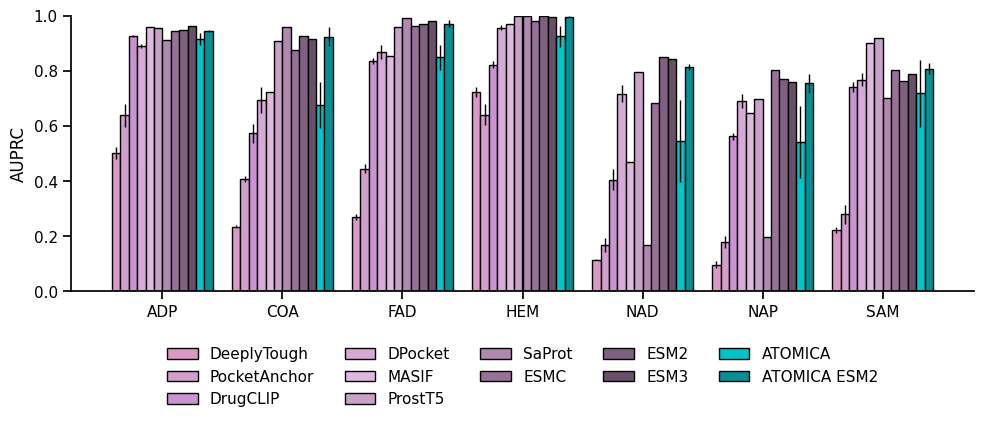

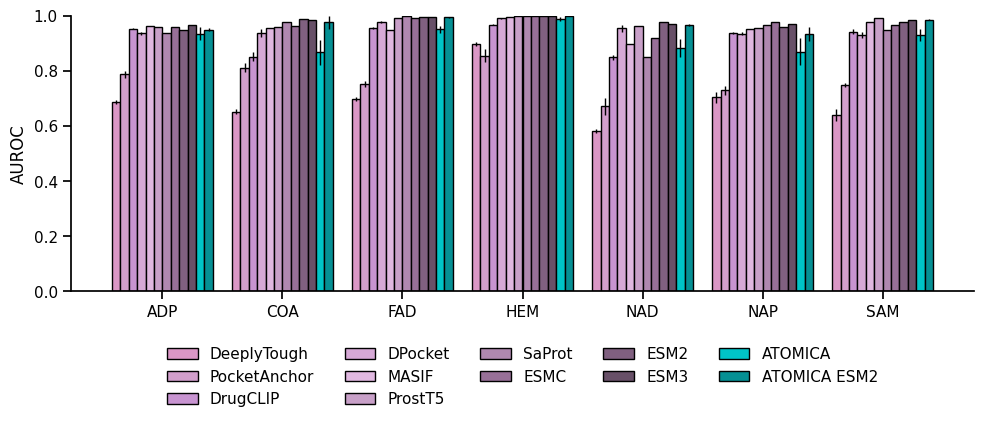

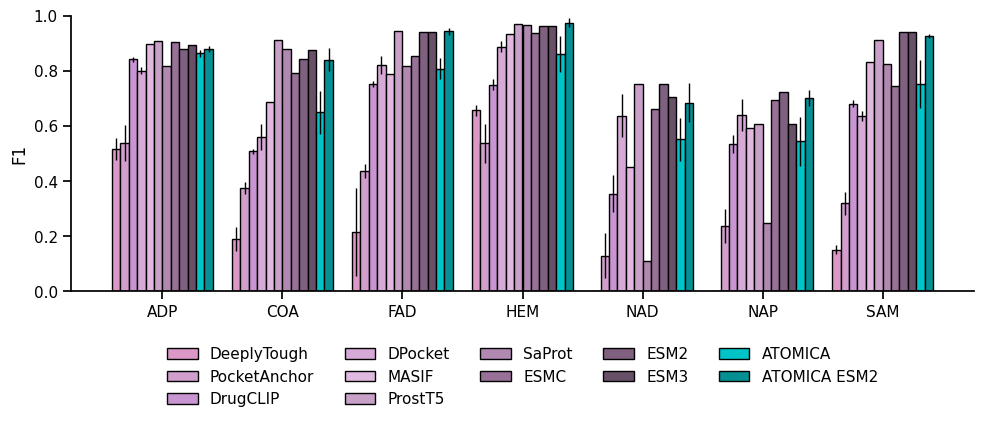

In [56]:
for metric in ['AUPRC', 'AUROC', 'F1']:
    plot_df = metrics_table_df[
        metrics_table_df['Metric'].str.endswith(metric) & 
        ~metrics_table_df['Metric'].str.contains('Avg')
    ].copy()

    plot_metric(plot_df, metric)

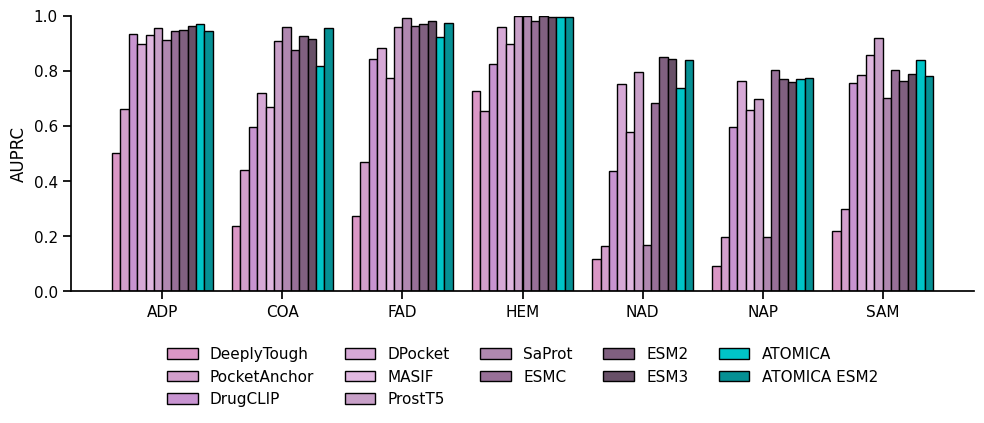

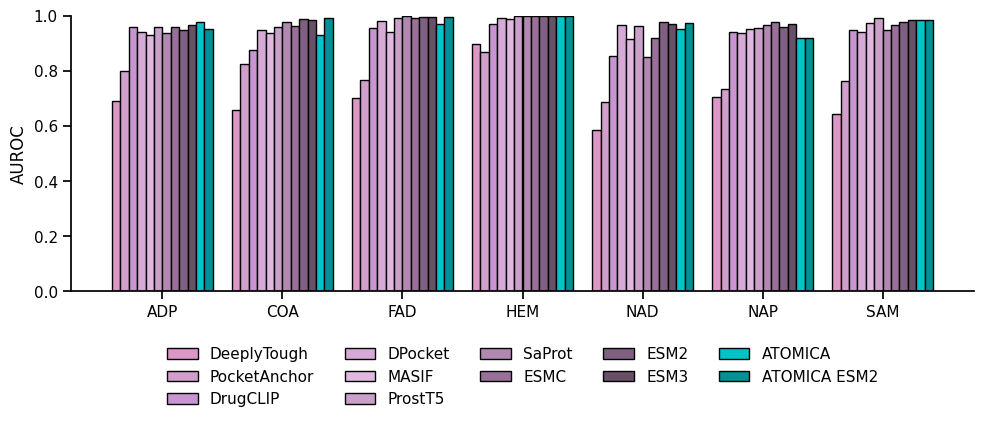

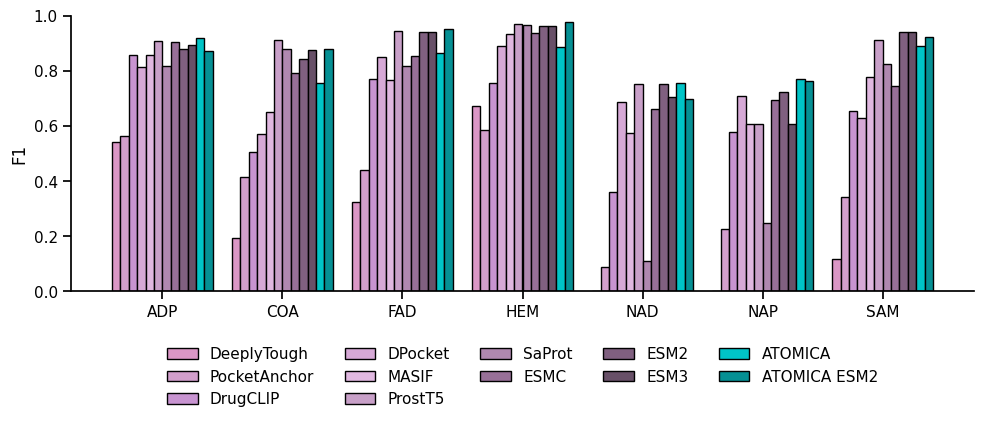

In [57]:
for metric in ['AUPRC', 'AUROC', 'F1']:
    plot_df = metrics_ensemble_table_df[
        metrics_ensemble_table_df['Metric'].str.endswith(metric) & 
        ~metrics_ensemble_table_df['Metric'].str.contains('Avg')
    ].copy()

    plot_metric(plot_df, metric)

In [58]:
def plot_aggregate_metrics(plot_df, metric1, metric2, y_label,plm=False):
    # Get unique models in order
    if plm:
        models = ['SaProt', 'ProstT5', 'ESMC', 'ESM2', 'ESM3', 'ATOMICA', 'ATOMICA ESM2']
        model_colors = [COLOR_SCHEME[m] for m in models]
    else:
        models = ['DeeplyTough', 'PocketAnchor', 'DrugCLIP', 'DPocket', 'MASIF', 'ATOMICA']
        model_colors = [COLOR_SCHEME[m] for m in models]
    
    # Separate micro and macro
    plot_df = plot_df[plot_df['Model'].isin(models)]
    micro_df = plot_df[plot_df['Metric'].str.contains(metric1)].copy()
    macro_df = plot_df[plot_df['Metric'].str.contains(metric2)].copy()

    n_models = len(models)

    # Prepare data for grouped bars
    width = 0.35  # Width of each bar
    spacing = 0.8  # Spacing between model groups

    # Create x positions with gaps between model groups
    x = np.arange(n_models) * spacing

    # Get values and errors for both metrics for each model
    f1_micro_means = []
    f1_micro_stds = []
    f1_macro_means = []
    f1_macro_stds = []

    use_std = 'Std' in micro_df.columns and 'Std' in macro_df.columns
    for model in models:
        micro_vals = micro_df[micro_df['Model'] == model]
        macro_vals = macro_df[macro_df['Model'] == model]
        f1_micro_means.append(micro_vals['Value'].values[0] if len(micro_vals) > 0 else 0)
        f1_macro_means.append(macro_vals['Value'].values[0] if len(macro_vals) > 0 else 0)
        if use_std:
            f1_micro_stds.append(micro_vals['Std'].values[0] if len(micro_vals) > 0 else 0)
            f1_macro_stds.append(macro_vals['Std'].values[0] if len(macro_vals) > 0 else 0)

    # Create the plot
    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot bars side by side with error bars
    # f1_micro bars (left, solid)
    for i, model in enumerate(models):
        if use_std:
            ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                color=model_colors[i], edgecolor='black', linewidth=1, 
                yerr=f1_micro_stds[i], capsize=0, error_kw={'linewidth': 1})
        else:
            ax.bar(x[i] - width/2, f1_micro_means[i], width, 
                color=model_colors[i], edgecolor='black', linewidth=1)

    # f1_macro bars (right, with diagonal hatching)
    for i, model in enumerate(models):
        if use_std:
            ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                color=model_colors[i], edgecolor='black', linewidth=1,
                hatch='///', yerr=f1_macro_stds[i], capsize=0, error_kw={'linewidth': 1})
        else:
            ax.bar(x[i] + width/2, f1_macro_means[i], width, 
                color=model_colors[i], edgecolor='black', linewidth=1, hatch='///')

    # Add text labels on top of bars
    for i in range(n_models):
        # F1 Micro label
        if use_std:
            y_pos_micro = f1_micro_means[i] + f1_micro_stds[i] + 0.01
            y_pos_macro = f1_macro_means[i] + f1_macro_stds[i] + 0.01
        else:
            y_pos_micro = f1_micro_means[i] + 0.01
            y_pos_macro = f1_macro_means[i] + 0.01
        ax.text(x[i] - width/2, y_pos_micro, f'{f1_micro_means[i]:.3f}', 
                ha='center', va='bottom', fontsize=8, rotation=0)
        
        ax.text(x[i] + width/2, y_pos_macro, f'{f1_macro_means[i]:.3f}', 
                ha='center', va='bottom', fontsize=8, rotation=0)

    # Create custom legend with grey color
    from matplotlib.patches import Rectangle
    legend_elements = [
        Rectangle((0, 0), 1, 1, facecolor='#E0B8E0', edgecolor='black', label=metric1),
        Rectangle((0, 0), 1, 1, facecolor='#E0B8E0', edgecolor='black', hatch='///', label=metric2)
    ]
    ax.legend(handles=legend_elements, loc='best', frameon=False)

    # Customize the plot
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_xlabel('', fontsize=12)
    ax.set_ylim(0.0, 1.0)
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    sns.despine()

    plt.tight_layout()
    plt.savefig(f'figures/masif_ligand_benchmark_aggregated_{metric1}_{metric2}.svg', format='svg', bbox_inches='tight')
    plt.show()

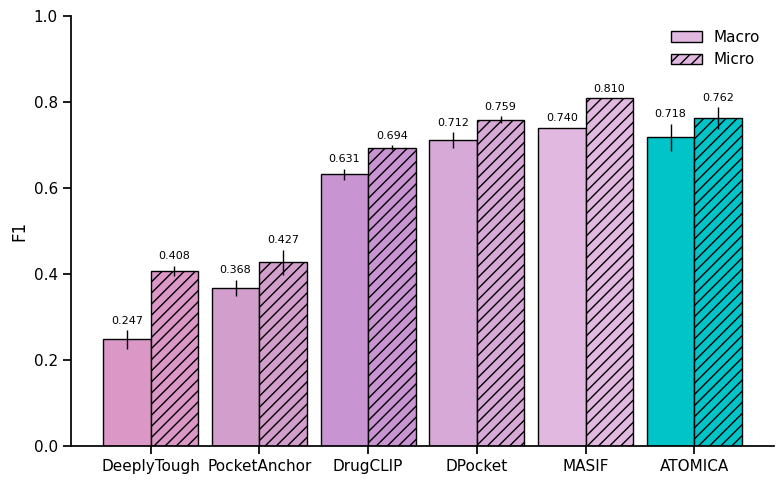

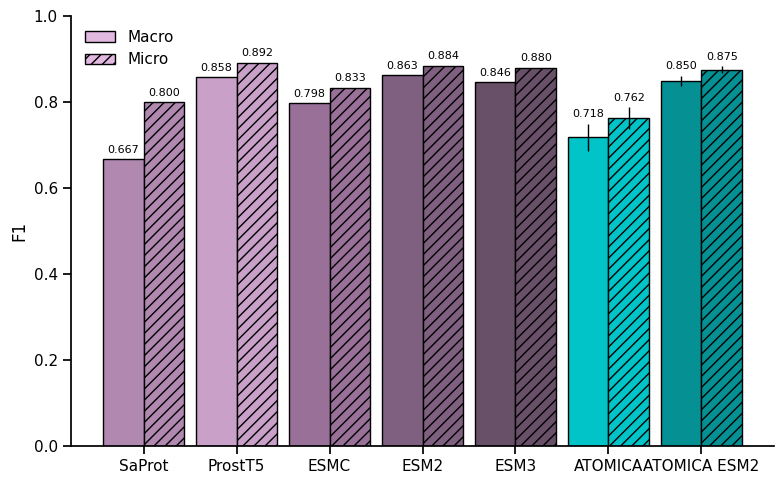

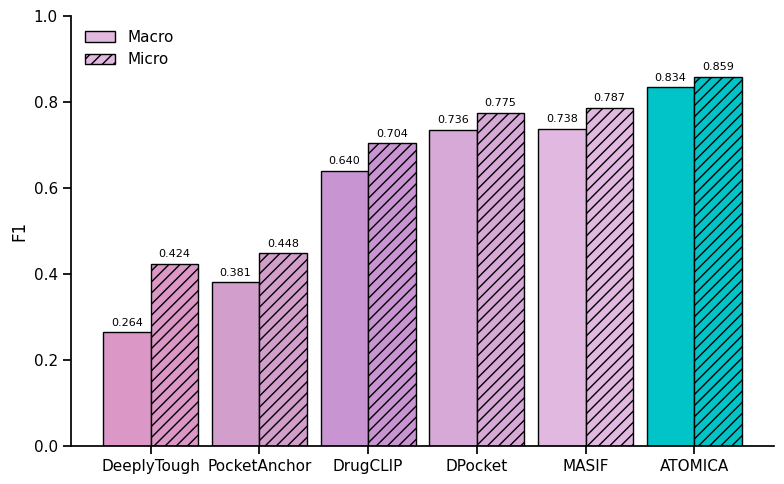

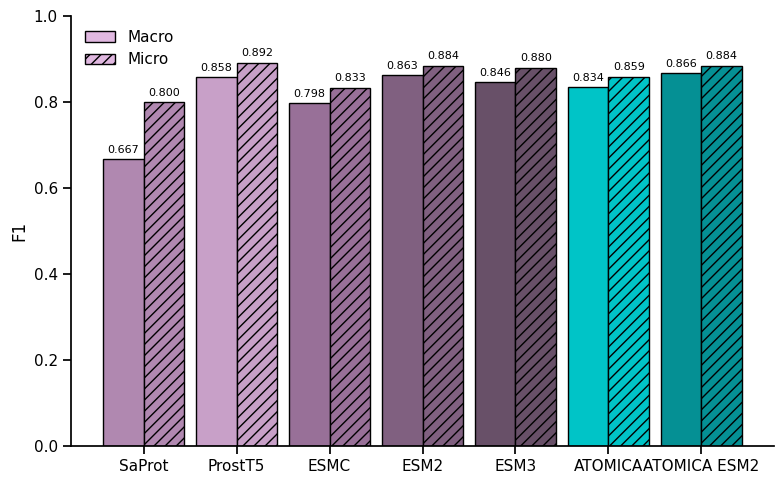

In [59]:
# Plot F1 Macro and Micro averages with error bars
plot_df = metrics_table_df[
    metrics_table_df['Metric'].str.endswith('F1') & 
    metrics_table_df['Metric'].str.contains('Avg')
].copy()

plot_aggregate_metrics(plot_df, 'Macro', 'Micro', 'F1', plm=False)
plot_aggregate_metrics(plot_df, 'Macro', 'Micro', 'F1', plm=True)


plot_df = metrics_ensemble_table_df[
    metrics_ensemble_table_df['Metric'].str.endswith('F1') & 
    metrics_ensemble_table_df['Metric'].str.contains('Avg')
].copy()

plot_aggregate_metrics(plot_df, 'Macro', 'Micro', 'F1', plm=False)
plot_aggregate_metrics(plot_df, 'Macro', 'Micro', 'F1', plm=True)

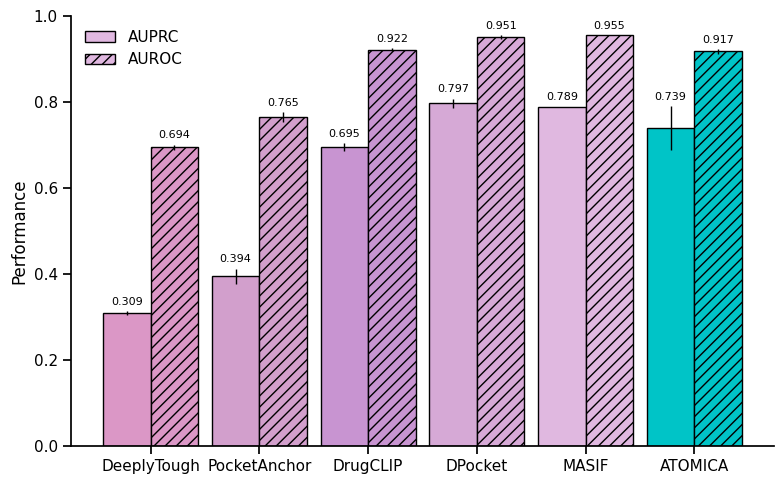

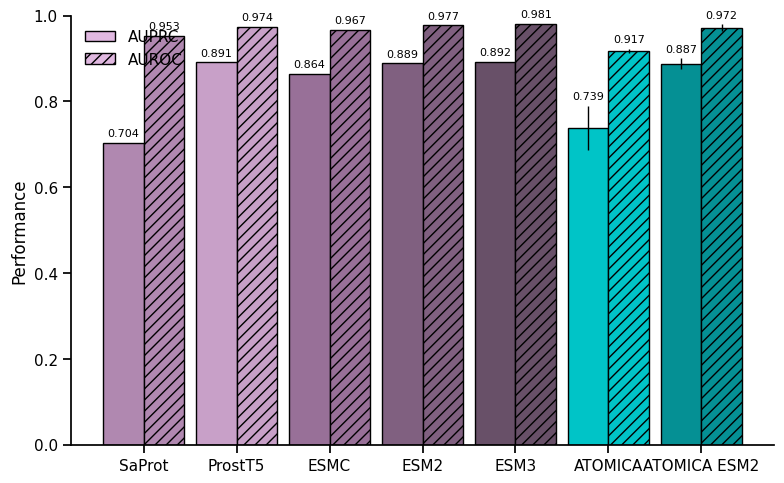

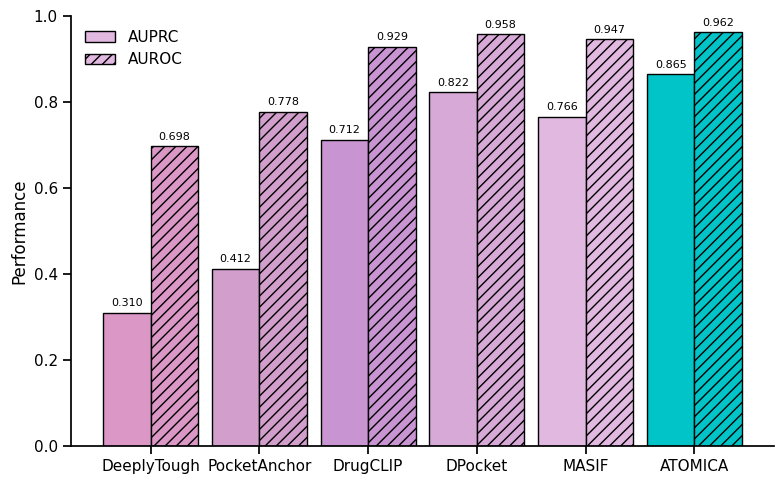

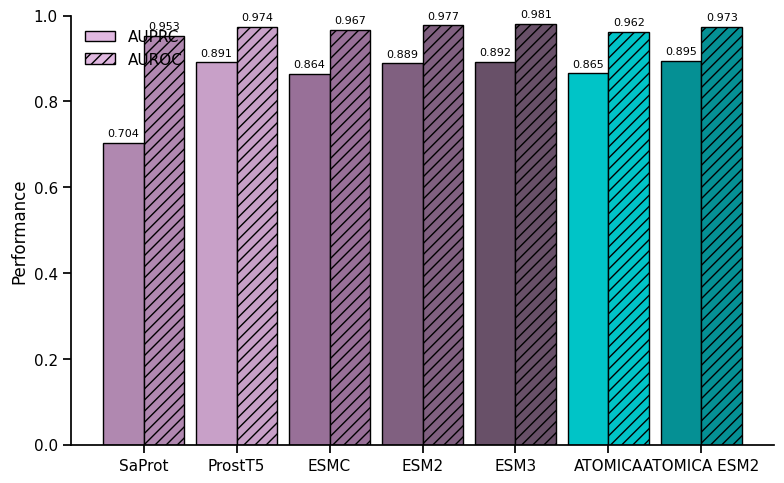

In [60]:
# Plot AUPRC and AUROC averages with error bars
plot_df = metrics_table_df[
    (metrics_table_df['Metric'].str.endswith('AUPRC') |
    metrics_table_df['Metric'].str.endswith('AUROC')) &
    metrics_table_df['Metric'].str.contains('Avg')
].copy()

plot_aggregate_metrics(plot_df, 'AUPRC', 'AUROC', 'Performance', plm=False)
plot_aggregate_metrics(plot_df, 'AUPRC', 'AUROC', 'Performance', plm=True)

plot_df = metrics_ensemble_table_df[
    (metrics_ensemble_table_df['Metric'].str.endswith('AUPRC') |
    metrics_ensemble_table_df['Metric'].str.endswith('AUROC')) &
    metrics_ensemble_table_df['Metric'].str.contains('Avg')
].copy()

plot_aggregate_metrics(plot_df, 'AUPRC', 'AUROC', 'Performance', plm=False)
plot_aggregate_metrics(plot_df, 'AUPRC', 'AUROC', 'Performance', plm=True)